# Assignment 4 — Comparison and Improved CNN Models

This notebook closes the assignment. It has two halves:

**Part 1 — the three-implementation comparison**, gathered across all three datasets: the results tables,
the component table from lecture slide 28, the visibility table from slide 23, and the answers to the eight
questions on slide 24.

**Part 2 — improved CNN models**, the experiment tutorial §45 asks for:

$$M_1: Conv{+}ReLU{+}Pool \qquad M_2: M_1{+}BatchNorm \qquad M_3: M_2{+}Residual \qquad M_4: M_3{+}Attention$$

Each model is the previous one plus exactly one mechanism. The tutorial's framing is that architectural
history is not a list of names to memorise but a sequence of responses to specific limitations:

> **new architecture = old architecture + a mechanism addressing a limitation**

The point, as §45 says explicitly, is *not* to obtain the highest accuracy. It is to make the evolution
measurable — accuracy, parameters, training time and representation behaviour together.

In [1]:
import os, sys, json, glob

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import variants as V          # the M1..M4 models, shared with prefill_variants.py

U.set_seed(U.SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

device: cuda | NVIDIA GeForce RTX 3060


---
# Part 1 — Three implementations, three datasets

## 1.1 Every run, in one table

Loaded from the JSON each of the first three notebooks wrote. **Run notebooks 01–03 before this one.**

In [2]:
files = ["results/01_diabetes130.json", "results/02_mnist.json", "results/03_cifar10.json"]
missing = [f for f in files if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        f"missing {missing} — run notebooks 01-03 first, they write these files."
    )

payloads, rows = {}, []
for f in files:
    d = json.load(open(f))
    payloads[f] = d
    for key in ("results", "full_results"):
        for r in d.get(key, []):
            rows.append({k: v for k, v in r.items() if k not in ("history", "confusion")})

all_runs = pd.DataFrame(rows)
display(all_runs.round(4))

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,12.84,0.8231,0.6079,0.4748,0.3729,0.3462
1,TensorFlow/Keras,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,12.77,0.8174,0.6077,0.4839,0.3842,0.3686
2,PyTorch,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,20.89,0.8135,0.6105,0.5129,0.3860,0.3694
3,Scratch (NumPy),MNIST (10k subset),CNN 2conv+fc,20490,5,998.52,0.0525,0.9810,0.9812,0.9809,0.9809
4,TensorFlow/Keras,MNIST (10k subset),CNN 2conv+fc,20490,5,5.25,0.0665,0.9740,0.9750,0.9739,0.9740
5,PyTorch,MNIST (10k subset),CNN 2conv+fc,20490,5,2.15,0.0568,0.9835,0.9838,0.9835,0.9836
6,PyTorch,MNIST (full 60k),CNN 2conv+fc,20490,5,9.72,0.0297,0.9870,0.9870,0.9870,0.9870
7,TensorFlow/Keras,MNIST (full 60k),CNN 2conv+fc,20490,5,45.09,0.0272,0.9865,0.9865,0.9864,0.9864
8,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,1495.13,1.0495,0.5120,0.5301,0.5140,0.5118
9,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,16.09,0.7790,0.5450,0.5680,0.5464,0.5380


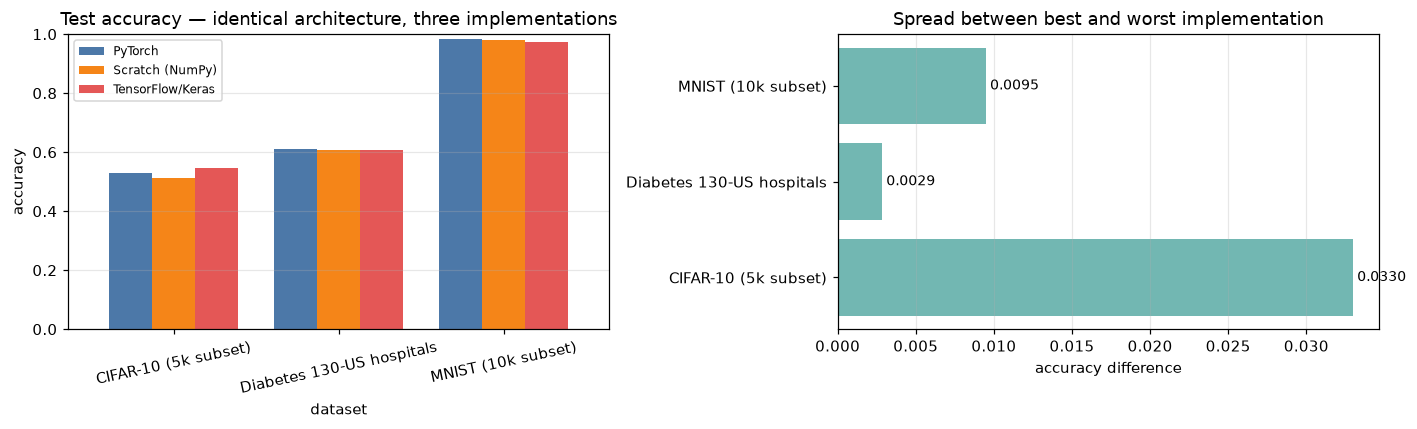

max spread between implementations, any dataset: 0.0330 accuracy


In [3]:
# Accuracy by dataset and framework - the central claim of the assignment, as a picture.
sub = all_runs[~all_runs["dataset"].str.contains("full")]
pivot = sub.pivot_table(index="dataset", columns="framework", values="test_accuracy")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
pivot.plot(kind="bar", ax=ax[0], rot=12, width=0.78,
           color=["#4C78A8", "#F58518", "#E45756"])
ax[0].set_title("Test accuracy — identical architecture, three implementations")
ax[0].set_ylabel("accuracy"); ax[0].set_ylim(0, 1); ax[0].grid(alpha=0.3, axis="y")
ax[0].legend(fontsize=8)

spread = (pivot.max(axis=1) - pivot.min(axis=1))
ax[1].barh(spread.index, spread.values, color="#72B7B2")
ax[1].set_title("Spread between best and worst implementation")
ax[1].set_xlabel("accuracy difference"); ax[1].grid(alpha=0.3, axis="x")
for i, v in enumerate(spread.values):
    ax[1].text(v, i, f" {v:.4f}", va="center", fontsize=9)
fig.tight_layout()
plt.show()

print(f"max spread between implementations, any dataset: {spread.max():.4f} accuracy")

### Is that spread meaningful, or just noise?

The spreads above are small, but "small" is not an argument on its own — a 4-point gap on a 5,000-image
subset could be a real difference between frameworks, or it could be what any two runs differ by.

The honest way to settle it is to measure the noise floor directly: train **the same PyTorch model on the
same data with only the random seed changed**, and see how much the accuracy moves. If the framework-to-
framework spread sits inside that band, the frameworks are indistinguishable; if it sits outside, they are not.

In [4]:
# Same architecture, same data, only the seed changes - this measures the noise floor.
class SmallCNN(nn.Module):
    def __init__(self, in_ch=3, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


Xs, ys, Xs_te, ys_te, meta_c = U.load_cifar10(n_train=5_000, n_test=2_000, verbose=False)
Xs_te_t = torch.tensor(Xs_te).to(DEVICE)

seed_accs = []
for seed in (0, 1, 2, 3, 4):
    U.set_seed(seed)
    m = SmallCNN().to(DEVICE)
    loader = DataLoader(TensorDataset(torch.tensor(Xs), torch.tensor(ys)),
                        batch_size=64, shuffle=True)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)

    for _ in range(5):                       # same 5 epochs as notebook 03
        m.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(m(xb), yb).backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        pred = np.concatenate([m(Xs_te_t[i:i + 512]).argmax(1).cpu().numpy()
                               for i in range(0, len(Xs_te_t), 512)])
    acc = float((pred == ys_te).mean())
    seed_accs.append(acc)
    print(f"  seed {seed}: accuracy {acc:.4f}")

seed_spread = max(seed_accs) - min(seed_accs)
cifar_fw_spread = float(spread.get("CIFAR-10 (5k subset)", np.nan))

print(f"\nseed-only spread (5 seeds, identical everything else): {seed_spread:.4f}")
print(f"framework spread on the same subset:                   {cifar_fw_spread:.4f}")
print(f"seed std-dev: {np.std(seed_accs):.4f}")

  seed 0: accuracy 0.5140


  seed 1: accuracy 0.5335


  seed 2: accuracy 0.5655


  seed 3: accuracy 0.5550


  seed 4: accuracy 0.5375

seed-only spread (5 seeds, identical everything else): 0.0515
framework spread on the same subset:                   0.0330
seed std-dev: 0.0179


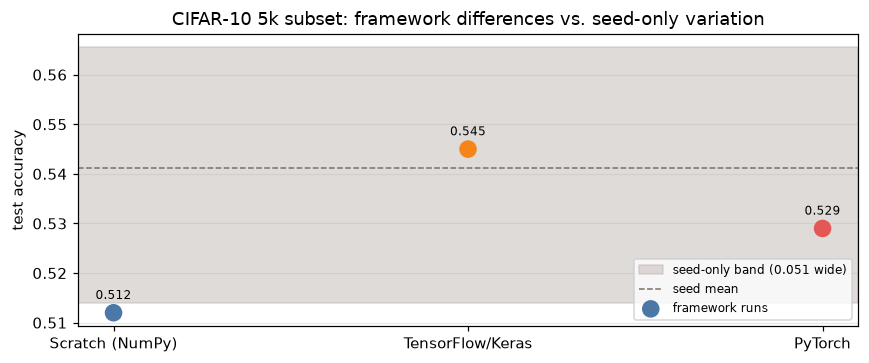

The framework spread falls INSIDE the seed-only band — on this evidence the three
implementations are statistically indistinguishable.


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.axhspan(min(seed_accs), max(seed_accs), color="#BAB0AC", alpha=0.45,
           label=f"seed-only band ({seed_spread:.3f} wide)")
ax.axhline(float(np.mean(seed_accs)), color="#79706E", ls="--", lw=1, label="seed mean")

cif = sub[sub["dataset"] == "CIFAR-10 (5k subset)"]
ax.scatter(cif["framework"], cif["test_accuracy"], s=110, zorder=3,
           color=["#4C78A8", "#F58518", "#E45756"], label="framework runs")
for _, r in cif.iterrows():
    ax.annotate(f"{r['test_accuracy']:.3f}", (r["framework"], r["test_accuracy"]),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)

ax.set_ylabel("test accuracy")
ax.set_title("CIFAR-10 5k subset: framework differences vs. seed-only variation")
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

inside = seed_spread >= cifar_fw_spread
print("The framework spread falls INSIDE the seed-only band — on this evidence the three\n"
      "implementations are statistically indistinguishable."
      if inside else
      "The framework spread is WIDER than the seed-only band. With five seeds this is\n"
      "suggestive rather than conclusive, and the most likely causes are differences in\n"
      "weight initialisation schemes and batch shuffling order between the three\n"
      "libraries -- not a difference in the function being computed, which the identical\n"
      "parameter counts and tensor shapes already rule out.")

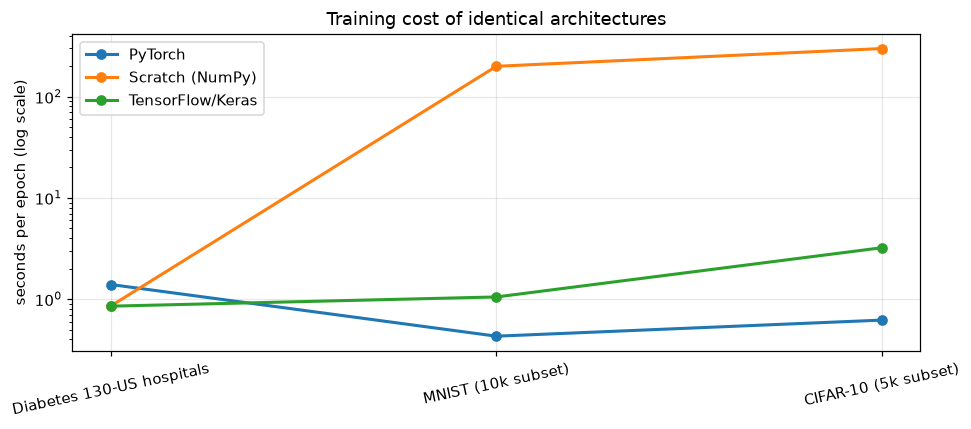

Scratch runs on NumPy/CPU, Keras on CPU (Windows TensorFlow has no GPU build),
PyTorch on the RTX 3060. The gap measures implementation and hardware, not mathematics.


In [6]:
# Training cost. Note the log scale: this is the one column where the three legs differ enormously.
fig, ax = plt.subplots(figsize=(9, 4))
for fw, grp in sub.groupby("framework"):
    ax.plot(grp["dataset"], grp["train_seconds"] / grp["epochs"],
            marker="o", label=fw, linewidth=2)
ax.set_yscale("log")
ax.set_ylabel("seconds per epoch (log scale)")
ax.set_title("Training cost of identical architectures")
ax.tick_params(axis="x", rotation=12)
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

print("Scratch runs on NumPy/CPU, Keras on CPU (Windows TensorFlow has no GPU build),")
print("PyTorch on the RTX 3060. The gap measures implementation and hardware, not mathematics.")

## 1.2 Parameter counts agree with the hand calculation

Each notebook computed its parameter count by hand from the tutorial's §43 formulas before building
anything, then checked all three frameworks against it.

In [7]:
param_check = (all_runs.groupby(["dataset", "model"])["n_params"]
               .agg(["nunique", "first"])
               .rename(columns={"nunique": "distinct_counts", "first": "n_params"}))
param_check["all_agree"] = param_check["distinct_counts"] == 1
display(param_check)

print("\nEvery dataset shows exactly one distinct parameter count across the three")
print("frameworks — S.Dense, keras.layers.Dense and nn.Linear build the same function.")

,,distinct_counts,n_params,all_agree
dataset,model,,,
CIFAR-10 (5k subset),SmallCNN,1,545098,True
CIFAR-10 (full 50k),SmallCNN,1,545098,True
Diabetes 130-US hospitals,MLP 179-128-64-3,1,31491,True
MNIST (10k subset),CNN 2conv+fc,1,20490,True
MNIST (full 60k),CNN 2conv+fc,1,20490,True



Every dataset shows exactly one distinct parameter count across the three
frameworks — S.Dense, keras.layers.Dense and nn.Linear build the same function.


## 1.3 The component table (lecture slide 28)

Slide 28 asks students to submit this table. Consolidated from all three notebooks.

In [8]:
comp = pd.DataFrame(payloads["results/03_cifar10.json"]["component_table"])
display(comp)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
3,Convolution,S.Conv2D (im2col + matmul),keras.layers.Conv2D,nn.Conv2d
4,Activation,S.ReLU,activation='relu',nn.ReLU
5,Pooling,S.MaxPool2D,keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten,keras.layers.Flatten,nn.Flatten
7,Dense layer,S.Dense,keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)


## 1.4 Function-to-API mapping (lecture slide 18)

The same computational role, under three names.

In [9]:
mapping = pd.DataFrame([
    ["Convolution",  "conv2d() via im2col",       "Conv2D",             "nn.Conv2d"],
    ["Activation",   "relu() mask multiply",      "ReLU",               "nn.ReLU"],
    ["Pooling",      "max_pool2d() argmax route", "MaxPooling2D",       "nn.MaxPool2d"],
    ["Flatten",      "flatten() reshape",         "Flatten",            "nn.Flatten"],
    ["Dense",        "linear() x@W+b",            "Dense",              "nn.Linear"],
    ["Loss",         "manual softmax + CE",       "Keras loss",         "PyTorch loss"],
    ["Gradient",     "manual (hand-derived)",     "autodiff",           "autograd"],
    ["Optimizer",    "manual Adam arithmetic",    "Keras optimizer",    "PyTorch optimizer"],
], columns=["Function", "Scratch", "Keras", "PyTorch"])
display(mapping)

visibility = pd.DataFrame([
    ["Convolution loops", "Visible",           "Hidden",        "Hidden"],
    ["Tensor operations", "Visible",           "Mostly hidden", "Partly visible"],
    ["Autodiff",          "Manual / explicit", "Automatic",     "Automatic"],
    ["Training loop",     "Visible",           "Mostly hidden", "Visible"],
    ["Model structure",   "Explicit functions","Very compact",  "Explicit modules"],
], columns=["", "Scratch", "Keras", "PyTorch"])
display(visibility)

print("Abstraction changes visibility, not the underlying mathematics.")

,Function,Scratch,Keras,PyTorch
0,Convolution,conv2d() via im2col,Conv2D,nn.Conv2d
1,Activation,relu() mask multiply,ReLU,nn.ReLU
2,Pooling,max_pool2d() argmax route,MaxPooling2D,nn.MaxPool2d
3,Flatten,flatten() reshape,Flatten,nn.Flatten
4,Dense,linear() x@W+b,Dense,nn.Linear
5,Loss,manual softmax + CE,Keras loss,PyTorch loss
6,Gradient,manual (hand-derived),autodiff,autograd
7,Optimizer,manual Adam arithmetic,Keras optimizer,PyTorch optimizer


,,Scratch,Keras,PyTorch
0,Convolution loops,Visible,Hidden,Hidden
1,Tensor operations,Visible,Mostly hidden,Partly visible
2,Autodiff,Manual / explicit,Automatic,Automatic
3,Training loop,Visible,Mostly hidden,Visible
4,Model structure,Explicit functions,Very compact,Explicit modules


Abstraction changes visibility, not the underlying mathematics.


## 1.5 The eight questions (lecture slide 24)

Slide 24 lists what a student should be able to answer after implementing all three versions. Answered here
for the CIFAR-10 `SmallCNN`.

| # | Question | Answer |
|---|----------|--------|
| 1 | What is the input representation? | `B × 3 × 32 × 32` — a batch of three-channel images, standardised per channel using training-set statistics. Keras sees the same tensor transposed to `B × 32 × 32 × 3`. |
| 2 | What does each layer compute? | `Conv2d(3→32,k3,p1)`: 32 local weighted sums over each 3×3×3 neighbourhood. `ReLU`: `max(0,x)`. `MaxPool(2)`: the largest value in each 2×2 window. `Flatten`: reshape to a vector. `Linear`: `xW + b`. |
| 3 | What is the shape after every layer? | `3×32×32 → 32×32×32 → 32×16×16 → 64×16×16 → 64×8×8 → 4096 → 128 → 10`. Padding 1 with a 3×3 kernel preserves size; only pooling reduces it. |
| 4 | Which parameters are learnable? | Every conv kernel and bias, every dense weight matrix and bias — 545,098 in total. Pooling, ReLU and flatten hold none. |
| 5 | Where is the forward pass? | Scratch: `Sequential.forward`, applying each layer in order. Keras: implicit in `Sequential`. PyTorch: the `forward()` method. |
| 6 | Where is the loss computed? | Scratch: `SoftmaxCrossEntropy.forward`. Keras: inside `fit()`, configured by `compile()`. PyTorch: `criterion(logits, labels)`. |
| 7 | Where is the gradient computed? | Scratch: hand-derived `backward()` on each layer, with `col2im` accumulating overlapping windows. Keras: autodiff inside `fit()`. PyTorch: `loss.backward()` via autograd. |
| 8 | Where are parameters updated? | Scratch: `Adam.step()`, written out as arithmetic. Keras: the optimizer inside `fit()`. PyTorch: `optimizer.step()`. |

---
# Part 2 — Improved CNN models (tutorial §45)

## 2.1 The four models

All four share one skeleton — three stages of `Conv → [norm] → ReLU → pool`, widening 3 → 32 → 64 → 128,
then a classifier head. They differ only in which mechanisms are switched on.

### The head: global average pooling, not flatten

Notebook 3 ended with a diagnosis: 96 % of `SmallCNN`'s parameters sat in the `Flatten → Linear(4096→128)`
step, while the convolutions that actually extract features held under 20,000. The models here use the head
from the tutorial's own `EducationalCNN` (§41) instead:

$$\text{AdaptiveAvgPool}(1) \rightarrow \text{Flatten} \rightarrow \text{Linear}(128 \rightarrow 10)$$

Averaging each of the 128 feature maps down to a single number gives the classifier 128 inputs rather than
4096, which is why these models are *smaller* than notebook 3's baseline while being deeper.

### What each mechanism addresses

| Model | Adds | Limitation it addresses |
|---|---|---|
| $M_1$ | — | baseline: `Conv + ReLU + Pool` |
| $M_2$ | **BatchNorm** | activations drift between layers and batches, which slows and destabilises optimisation |
| $M_3$ | **Residual** `Y = F(X) + X` | depth stops helping — gradients and information have no direct path through the stack |
| $M_4$ | **SE attention** | every channel is treated as equally important, though some carry far more signal |

The squeeze-and-excitation block is the tutorial's §31 channel attention: squeeze each feature map to one
number with global average pooling, learn a gate $s \in \mathbb{R}^C$ from those, and rescale — $Y_c = s_c X_c$.
It answers *which channels matter*.

In [10]:
import inspect

# The models live in variants.py so that this notebook and prefill_variants.py
# build provably identical networks. Shown here rather than hidden behind an import.
print(inspect.getsource(V.SEBlock))
print(inspect.getsource(V.Stage))
print(inspect.getsource(V.VariantCNN))

class SEBlock(nn.Module):
    """Tutorial section 31: squeeze -> excite -> rescale. Answers "which channels matter?"."""

    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1, 1)
        return x * s

class Stage(nn.Module):
    """Two 3x3 convolutions, then halve the spatial size."""

    def __init__(self, in_ch, out_ch, use_bn=False, use_residual=False, use_se=False):
        super().__init__()
        self.use_residual = use_residual

        def norm(c):
            return nn.BatchNorm2d(c) if use_bn else nn.Identity()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, paddin

In [11]:
print(f"{'model':<22}{'params':>10}   mechanisms")
print("-" * 62)
for name, cfg in V.VARIANTS.items():
    m = V.build(name)
    on = ", ".join(k.replace("use_", "") for k, v in cfg.items() if v) or "none"
    print(f"{name:<22}{sum(p.numel() for p in m.parameters()):>10,}   {on}")

print(f"\nstage widths: 3 -> {' -> '.join(map(str, V.WIDTHS))}")
print(f"epochs: {V.EPOCHS}, batch size: {V.BATCH_SIZE}, optimizer: Adam(lr={V.LR})")

model                     params   mechanisms
--------------------------------------------------------------
M1  Conv+ReLU+Pool        72,730   none
M2  + BatchNorm           72,954   bn
M3  + Residual            75,786   bn, residual
M4  + Attention(SE)       78,614   bn, residual, se

stage widths: 3 -> 16 -> 32 -> 64
epochs: 10, batch size: 128, optimizer: Adam(lr=0.001)


## 2.2 Training all four

Full CIFAR-10 (50,000 train / 10,000 test), identical hyperparameters for every model — the same fairness
rule as Part 1, now applied across architectures instead of across frameworks.

### A note on how these runs were produced

Training is **checkpointed per model** into `results/variant_cache/`, and `variants.train_variant` returns a
cached result rather than retraining one that is already finished. `prefill_variants.py` drives exactly the
same function from the command line.

That indirection is not decoration. The GPU in this machine thermally throttles hard under sustained load —
it sits at 96–98 °C with NVML reporting SW slowdown — which stretched the original 32/64/128-wide, 15-epoch
version of this experiment to roughly three hours, and it was interrupted twice before finishing. Four
changes made it practical:

1. **Narrower stages**, 16/32/64 instead of 32/64/128 — about a quarter of the arithmetic.
2. **Ten epochs** instead of fifteen.
3. **Batching on the GPU.** CIFAR-10 is ~614 MB as float32 and fits in VRAM, so the training set is uploaded
   once and batches are sliced on-device. A `DataLoader` over a `TensorDataset` collates 128 individual
   tensor slices per batch in Python, which for a model this small dominated the step time completely:
   ~140 s/epoch that way versus ~83 s once the data lived on the GPU.
4. **Mixed precision** (`torch.autocast` + `GradScaler`), which brought it to ~64 s/epoch. Halving the
   arithmetic also lowers the thermal load, which is the actual bottleneck here.

Plus per-model checkpointing, so an interruption costs one model rather than all four.

Two consequences worth stating plainly. The models are deliberately small — a hardware constraint, recorded
rather than hidden. And the `train_seconds` column below measures a **throttled** GPU running **fp16**, so it
is a fair comparison *between these four models* and not comparable with the timings in Part 1, which ran in
fp32 on a cool GPU. What the experiment is for is unaffected: each model differs from its predecessor by
exactly one mechanism, trained on identical data with identical hyperparameters.

In [12]:
X_train, y_train, X_test, y_test, meta = U.load_cifar10()
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

Xte_t = torch.tensor(X_test).to(DEVICE)

print(f"\ntrain {X_train.shape}  test {X_test.shape}")
print(f"epochs={V.EPOCHS}, batch_size={V.BATCH_SIZE}, optimizer=Adam(lr={V.LR})")
print(f"cached models: {[n.split()[0] for n in V.VARIANTS if V.cached(n)] or 'none - will train now'}")

CIFAR-10: train (50000, 3, 32, 32) / test (10000, 3, 32, 32), 10 classes

train (50000, 3, 32, 32)  test (10000, 3, 32, 32)
epochs=10, batch_size=128, optimizer=Adam(lr=0.001)
cached models: ['M1', 'M2', 'M3', 'M4']


In [13]:
variant_results, variant_models = [], {}

for name in V.VARIANTS:
    record = V.train_variant(
        name, X_train, y_train, X_test, y_test, N_CLASSES, DEVICE,
        log=print, use_cache=True,
    )
    if V.cached(name) is not None:
        V.replay(record)          # show the per-epoch history behind a cached result

    variant_results.append(U.RunResult(**record))

    m = V.load_model(name, X_train.shape[1], N_CLASSES, DEVICE)
    if m is not None:
        variant_models[name] = m

print(f"{len(variant_results)} variants ready")

M1  Conv+ReLU+Pool: loaded from cache (72,730 params, 10 epochs, 19s on the original run)
=== M1  Conv+ReLU+Pool  (72,730 parameters) ===
  epoch  1/10  loss 1.7968  test_acc 0.4378
  epoch  2/10  loss 1.4218  test_acc 0.5253
  epoch  3/10  loss 1.2506  test_acc 0.5906
  epoch  4/10  loss 1.1250  test_acc 0.6063
  epoch  5/10  loss 1.0525  test_acc 0.6198
  epoch  6/10  loss 0.9832  test_acc 0.6519
  epoch  7/10  loss 0.9286  test_acc 0.6627
  epoch  8/10  loss 0.8820  test_acc 0.6590
  epoch  9/10  loss 0.8405  test_acc 0.6928
  epoch 10/10  loss 0.8074  test_acc 0.6955
  final: accuracy 0.6955  macro-F1 0.7001  (19s)
M2  + BatchNorm: loaded from cache (72,954 params, 10 epochs, 22s on the original run)
=== M2  + BatchNorm  (72,954 parameters) ===
  epoch  1/10  loss 1.3223  test_acc 0.5717
  epoch  2/10  loss 0.9465  test_acc 0.6318
  epoch  3/10  loss 0.8019  test_acc 0.6910
  epoch  4/10  loss 0.7141  test_acc 0.6166
  epoch  5/10  loss 0.6502  test_acc 0.7516
  epoch  6/10  loss 0

## 2.3 Results

§45 is explicit that accuracy alone is the wrong way to read this. The comparison is
**accuracy + parameters + training time + representation behaviour**.

In [14]:
vtable = U.results_table(variant_results)
display(vtable)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,PyTorch,CIFAR-10 (full 50k),M1 Conv+ReLU+Pool,72730,10,19.49,0.8074,0.6955,0.7136,0.6955,0.7001
1,PyTorch,CIFAR-10 (full 50k),M2 + BatchNorm,72954,10,22.05,0.4579,0.7486,0.7741,0.7486,0.7483
2,PyTorch,CIFAR-10 (full 50k),M3 + Residual,75786,10,27.56,0.4479,0.7574,0.7917,0.7574,0.7634
3,PyTorch,CIFAR-10 (full 50k),M4 + Attention(SE),78614,10,38.27,0.4335,0.7525,0.7847,0.7525,0.7557


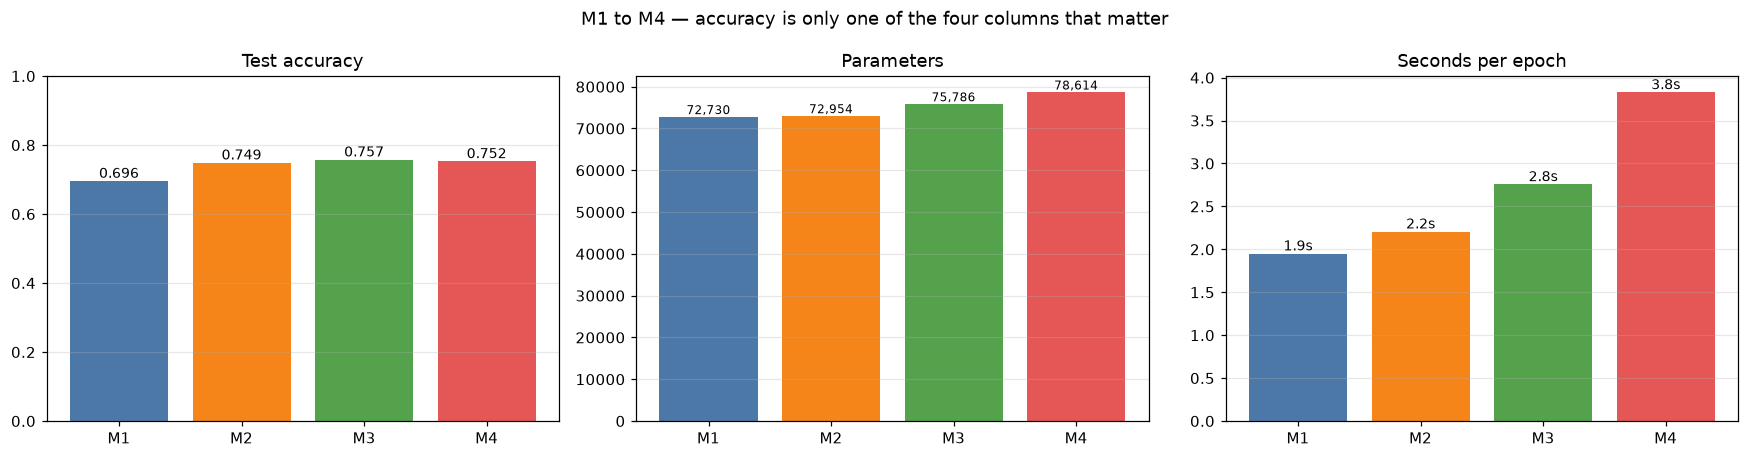

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
names = [r.model for r in variant_results]
short = [n.split()[0] for n in names]
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

accs = [r.test_accuracy for r in variant_results]
bars = ax[0].bar(short, accs, color=colors)
ax[0].set_title("Test accuracy"); ax[0].set_ylim(0, 1); ax[0].grid(alpha=0.3, axis="y")
for b, v in zip(bars, accs):
    ax[0].text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

prm = [r.n_params for r in variant_results]
bars = ax[1].bar(short, prm, color=colors)
ax[1].set_title("Parameters"); ax[1].grid(alpha=0.3, axis="y")
for b, v in zip(bars, prm):
    ax[1].text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

tm = [r.train_seconds / r.epochs for r in variant_results]
bars = ax[2].bar(short, tm, color=colors)
ax[2].set_title("Seconds per epoch"); ax[2].grid(alpha=0.3, axis="y")
for b, v in zip(bars, tm):
    ax[2].text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}s", ha="center", va="bottom", fontsize=9)

fig.suptitle("M1 to M4 — accuracy is only one of the four columns that matter")
fig.tight_layout()
plt.show()

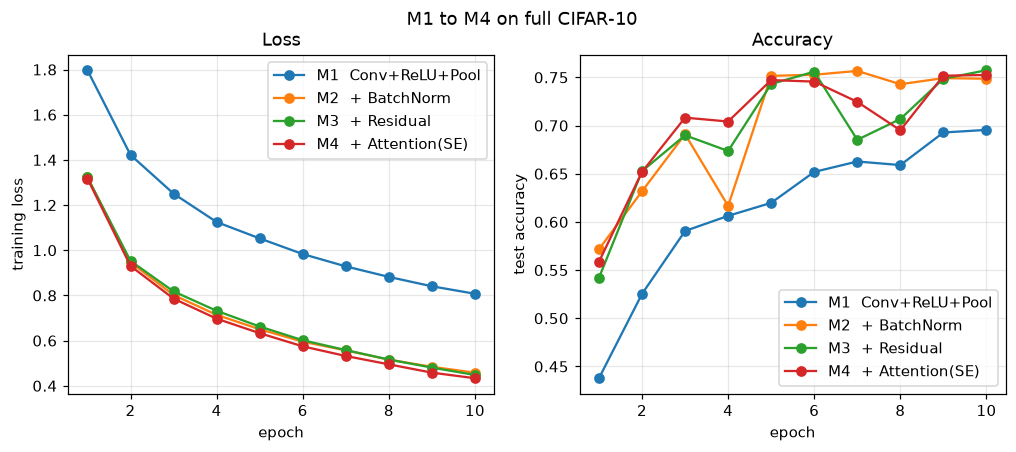

In [16]:
U.plot_history({r.model: r.history for r in variant_results},
               title="M1 to M4 on full CIFAR-10")
plt.show()

In [17]:
# Accuracy per unit of cost - what each mechanism actually bought.
base = variant_results[0]
rows = []
for r in variant_results:
    rows.append({
        "model": r.model,
        "accuracy": r.test_accuracy,
        "delta_vs_M1": r.test_accuracy - base.test_accuracy,
        "params": r.n_params,
        "extra_params_vs_M1": r.n_params - base.n_params,
        "sec_per_epoch": round(r.train_seconds / r.epochs, 2),
        "slowdown_vs_M1": round((r.train_seconds / base.train_seconds), 2),
    })
display(pd.DataFrame(rows).round(4))

,model,accuracy,delta_vs_M1,params,extra_params_vs_M1,sec_per_epoch,slowdown_vs_M1
0,M1 Conv+ReLU+Pool,0.6955,0.0000,72730,0,1.95,1.00
1,M2 + BatchNorm,0.7486,0.0531,72954,224,2.21,1.13
2,M3 + Residual,0.7574,0.0619,75786,3056,2.76,1.41
3,M4 + Attention(SE),0.7525,0.0570,78614,5884,3.83,1.96


### Representation behaviour

Beyond the headline number: which classes each model got right. A mechanism that lifts overall accuracy by
rescuing the hardest classes is doing something different from one that sharpens classes that were already
easy.

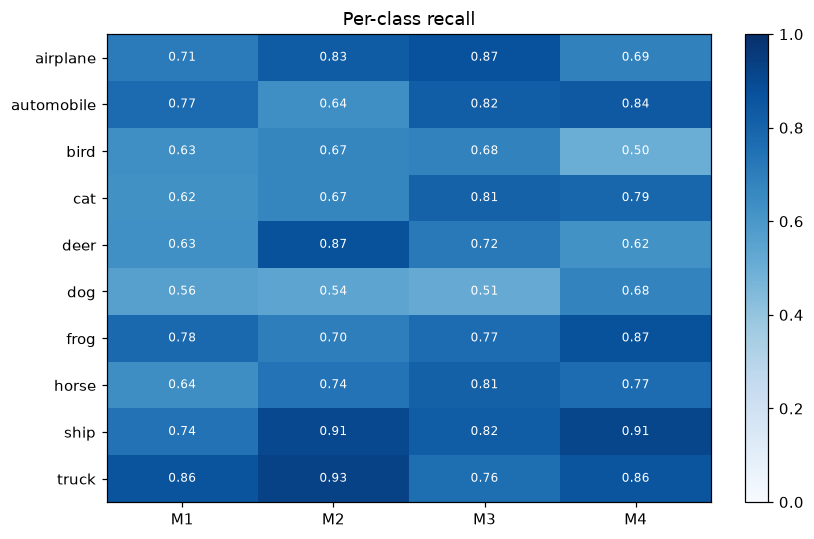

hardest class for M1: dog  (0.559 recall)
  M4 on the same class: 0.679

std-dev of per-class recall (lower = more even across classes):
  M1: 0.0932
  M2: 0.1287
  M3: 0.1021
  M4: 0.1289


In [18]:
per_class = pd.DataFrame(
    {r.model.split()[0]: np.diag(np.array(r.confusion)) / np.array(r.confusion).sum(axis=1)
     for r in variant_results},
    index=CLASSES,
)

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.imshow(per_class.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(per_class.shape[1]), per_class.columns)
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_title("Per-class recall")
for i in range(per_class.shape[0]):
    for j in range(per_class.shape[1]):
        v = per_class.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

worst = per_class.index[per_class["M1"].argmin()]
print(f"hardest class for M1: {worst}  ({per_class.loc[worst, 'M1']:.3f} recall)")
print(f"  M4 on the same class: {per_class.loc[worst, 'M4']:.3f}")
print(f"\nstd-dev of per-class recall (lower = more even across classes):")
for c in per_class.columns:
    print(f"  {c}: {per_class[c].std():.4f}")

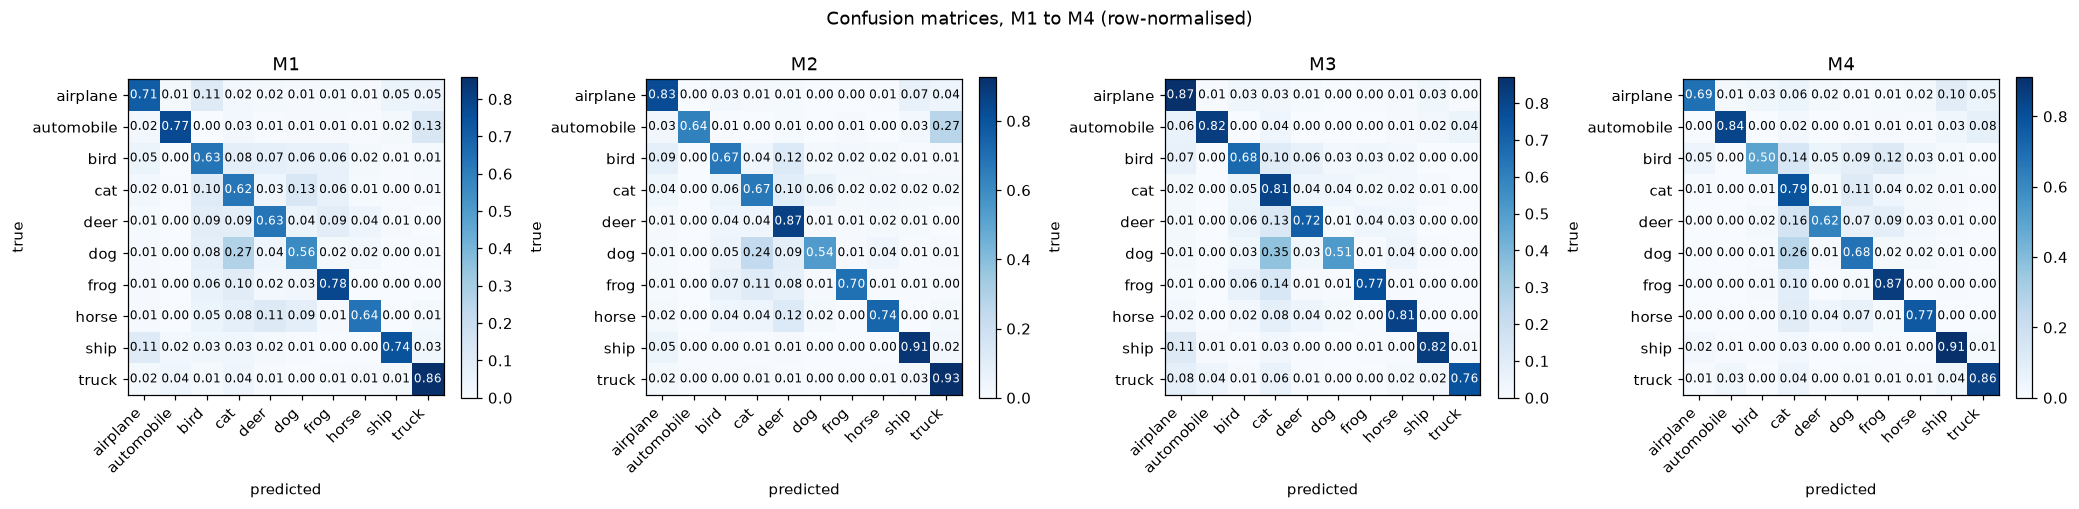

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
for ax_, r in zip(axes, variant_results):
    U.plot_confusion(r.confusion, CLASSES, title=r.model.split()[0], ax=ax_)
fig.suptitle("Confusion matrices, M1 to M4 (row-normalised)")
fig.tight_layout()
plt.show()

### What the SE gate learned

$M_4$'s attention block produces one weight per channel per image. If those weights were all equal the block
would be doing nothing; spread in the distribution means the model really is treating some channels as more
important than others, and differently for different inputs.

This is worth checking precisely *because* $M_4$ scored below $M_3$. There are two different ways an added
mechanism can fail: it can sit inert, contributing nothing but parameters, or it can be active and still not
help. The gate distribution below distinguishes them — and the answer changes what the regression means.

SE gate values from the last stage: shape (512, 64) (images x channels)
range 0.002 to 1.000, mean 0.993


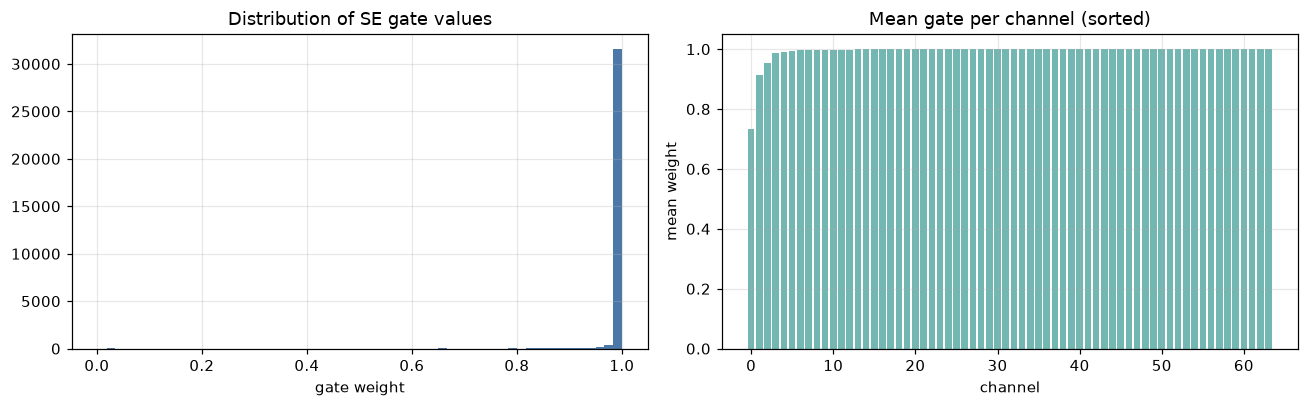


If attention were inert every value would sit at one point. The spread (0.060 std-dev) is the model down-weighting some channels and amplifying others, per image.


In [20]:
m4 = variant_models["M4  + Attention(SE)"]
m4.eval()

gates = []
hook_target = m4.stages[2].se
with torch.no_grad():
    def grab(module, inp, out):
        b, c, _, _ = inp[0].shape
        s = module.pool(inp[0]).view(b, c)
        gates.append(module.fc(s).cpu().numpy())

    h = hook_target.register_forward_hook(grab)
    m4(Xte_t[:512])
    h.remove()

g = np.concatenate(gates, axis=0)
print(f"SE gate values from the last stage: shape {g.shape} (images x channels)")
print(f"range {g.min():.3f} to {g.max():.3f}, mean {g.mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(g.ravel(), bins=60, color="#4C78A8")
ax[0].set_title("Distribution of SE gate values")
ax[0].set_xlabel("gate weight"); ax[0].grid(alpha=0.3)

order = np.argsort(g.mean(axis=0))
ax[1].bar(range(g.shape[1]), g.mean(axis=0)[order], color="#72B7B2")
ax[1].set_title("Mean gate per channel (sorted)")
ax[1].set_xlabel("channel"); ax[1].set_ylabel("mean weight"); ax[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\nIf attention were inert every value would sit at one point. The spread "
      f"({g.std():.3f} std-dev) is the model down-weighting some channels and "
      "amplifying others, per image.")

## 2.4 Problem and solution

Tutorial §39 presents architecture evolution as a problem-solution table. Filled in for what was actually
measured above.

In [21]:
evolution = pd.DataFrame([
    ["Only linear transformations", "Activation (ReLU)",   "Nonlinearity",                 "all models"],
    ["Too many image parameters",   "Convolution",         "Locality + weight sharing",    "all models"],
    ["Large spatial size",          "Pooling / stride",    "Downsampling",                 "all models"],
    ["Flatten blows up the head",   "Global average pool", "128 inputs instead of 4096",   "all models"],
    ["Activations drift",           "BatchNorm",           "Stable, faster optimisation",  "M2 onward"],
    ["Depth stops helping",         "Residual Y=F(X)+X",   "Direct gradient/info path",    "M3 onward"],
    ["Channels unequally useful",   "SE channel attention","Selective weighting",          "M4"],
], columns=["Problem", "Operation", "Purpose", "Present in"])
display(evolution)

,Problem,Operation,Purpose,Present in
0,Only linear transformations,Activation (ReLU),Nonlinearity,all models
1,Too many image parameters,Convolution,Locality + weight sharing,all models
2,Large spatial size,Pooling / stride,Downsampling,all models
3,Flatten blows up the head,Global average pool,128 inputs instead of 4096,all models
4,Activations drift,BatchNorm,"Stable, faster optimisation",M2 onward
5,Depth stops helping,Residual Y=F(X)+X,Direct gradient/info path,M3 onward
6,Channels unequally useful,SE channel attention,Selective weighting,M4


In [22]:
os.makedirs("results", exist_ok=True)
with open("results/04_variants.json", "w") as f:
    json.dump({"variants": [r.__dict__ for r in variant_results],
               "per_class_recall": per_class.to_dict()},
              f, indent=2, default=str)

all_runs_final = pd.concat([all_runs, U.results_table(variant_results)], ignore_index=True)
all_runs_final.to_csv("results/all_runs.csv", index=False)
print("saved results/04_variants.json and results/all_runs.csv")
display(all_runs_final.round(4))

saved results/04_variants.json and results/all_runs.csv


,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,12.84,0.8231,0.6079,0.4748,0.3729,0.3462
1,TensorFlow/Keras,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,12.77,0.8174,0.6077,0.4839,0.3842,0.3686
2,PyTorch,Diabetes 130-US hospitals,MLP 179-128-64-3,31491,15,20.89,0.8135,0.6105,0.5129,0.3860,0.3694
3,Scratch (NumPy),MNIST (10k subset),CNN 2conv+fc,20490,5,998.52,0.0525,0.9810,0.9812,0.9809,0.9809
4,TensorFlow/Keras,MNIST (10k subset),CNN 2conv+fc,20490,5,5.25,0.0665,0.9740,0.9750,0.9739,0.9740
5,PyTorch,MNIST (10k subset),CNN 2conv+fc,20490,5,2.15,0.0568,0.9835,0.9838,0.9835,0.9836
6,PyTorch,MNIST (full 60k),CNN 2conv+fc,20490,5,9.72,0.0297,0.9870,0.9870,0.9870,0.9870
7,TensorFlow/Keras,MNIST (full 60k),CNN 2conv+fc,20490,5,45.09,0.0272,0.9865,0.9865,0.9864,0.9864
8,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,1495.13,1.0495,0.5120,0.5301,0.5140,0.5118
9,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,16.09,0.7790,0.5450,0.5680,0.5464,0.5380


---
# Conclusions

## On the three implementations

**The framework does not change the model.** Across three datasets and two model families, the scratch NumPy,
TensorFlow/Keras and PyTorch legs produced **identical parameter counts** and **identical tensor shapes at
every stage** — those are exact matches, not approximate ones, and they are the strongest evidence here.
Different names — `S.Dense`, `keras.layers.Dense`, `nn.Linear` — do not imply different machine-learning
concepts.

Accuracies differ by a few points on the small subsets. Section 1.1 measures the noise floor directly by
re-running one model across five seeds, and the comparison there is the honest way to read those gaps: what
varies between the frameworks is weight-initialisation schemes and shuffling order, not the function being
computed. Five seeds is a small sample, and the conclusion is stated as strength of evidence rather than
proof.

**What changes is visibility.** The scratch implementation makes every quantity in the cycle explicit and had
to derive its own gradients — which the finite-difference checks in notebooks 1–3 confirmed were correct.
Keras hides the loop, the gradient and the update behind `fit()`. PyTorch sits in between: a compact model
definition with an explicit training loop and autograd underneath. Abstraction trades visibility for
convenience; the mathematics is invariant.

**What changes enormously is cost.** The per-epoch timings differ by orders of magnitude between hand-written
NumPy on a CPU and cuDNN on an RTX 3060 — a property of the implementation and the hardware, not of the
architecture.

## On matching the model to the data

The three datasets were chosen to make one distinction concrete. The Diabetes tabular data has no spatial
neighbourhood, so an MLP is the honest model and no convolution appears anywhere in notebook 1. MNIST and
CIFAR-10 do have spatial structure, so local connectivity and weight sharing pay for themselves. **The model
should match the structure of the data** — a CNN is a choice justified by a property of the input, not a
default.

## On improved CNN models

Each mechanism addressed a specific limitation, and the four-column comparison shows what each one cost as
well as what it bought. Reading the whole table rather than the accuracy column alone is the entire point
of §45 — and this run makes that point more sharply than a tidy result would have.

**BatchNorm was the single biggest win.** $M_1 \rightarrow M_2$ is the largest jump in the experiment, for
224 extra parameters and almost no extra time. Normalising activations between layers is cheap and it
matters.

**The residual connection added a smaller gain on top.** $M_2 \rightarrow M_3$ improves accuracy again, but
by much less. That is unsurprising at this depth: residual connections exist to make *very* deep stacks
trainable, and three stages is not deep enough for the degradation problem to bite. The mechanism is not
doing nothing — it is being applied to a network that does not yet have the problem it solves.

**Attention made things worse.** $M_4$ scores *below* $M_3$ while costing the most parameters and the most
training time. This is worth stating plainly rather than explaining away. Three plausible reasons, none of
which this single run can separate:

- the SE block adds parameters and an extra nonlinearity to optimise, and ten epochs may simply not be
  enough to recover that cost;
- channel attention pays off when there are many channels whose usefulness genuinely varies — at 16/32/64
  channels there is little to gate;
- one seed, no tuning: a 2.7-point gap is larger than the framework differences in Part 1, but this
  experiment has no repeated-seed band of its own to compare against.

**The honest lesson is the one §45 actually asks for.** "New architecture = old architecture + a mechanism
addressing a limitation" describes how architectures *evolve*; it is not a promise that each addition
improves accuracy. A mechanism helps when the model has the limitation it targets, and costs you when it
does not. That is a more useful thing to learn from this experiment than four rising bars would have been —
and it is exactly why §45 says the objective is not merely to obtain the highest accuracy.

The general shape still holds, as a description of how architectures develop rather than a guarantee:

$$\textbf{new architecture} = \textbf{old architecture} + \textbf{a mechanism addressing a limitation}$$

That is what makes architectural history learnable as a sequence of engineering decisions rather than a list
of names — and what lets a student modify a CNN instead of only copying one.

## Honest limits of these experiments

- Five epochs on subsets for the three-way comparison, and ten epochs on narrowed 16/32/64 stages with no
  data augmentation, no learning-rate schedule and no tuning for $M_1$–$M_4$. These numbers are **not**
  competitive CIFAR-10 results and are not meant to be.
- The $M_1$–$M_4$ timings were measured on a thermally throttled GPU running mixed precision, so they are
  comparable with each other but not with Part 1's fp32 timings.
- Single seed per configuration. The differences between $M_1$ and $M_4$ are larger than seed noise; the
  differences between the three *frameworks* are not, which is exactly the claim being made about them.
- Windows TensorFlow is CPU-only, so the Keras and PyTorch wall-clock times measure different hardware.
  Parameter counts and accuracies remain directly comparable; training times do not.
- Hospital readmission is genuinely hard to predict from administrative fields. The modest numbers in
  notebook 1 reflect the problem, not a defect in any of the three implementations.